In [3]:
import xarray as xr

In [4]:
import glob

files = sorted(glob.glob('BUI/BUI/BUI*.nc'))
print(len(files), files[:5], files[-5:])

# Peek at first two
for f in files[:3]:
    with xr.open_dataset(f) as ds:
        print(f, ds['time'].load().values[:3], ds['time'].load().values[-3:])

432 ['BUI/data/BUIY1980M10_.nc', 'BUI/data/BUIY1980M11_.nc', 'BUI/data/BUIY1980M12_.nc', 'BUI/data/BUIY1981M10_.nc', 'BUI/data/BUIY1981M11_.nc'] ['BUI/data/BUI_Y2015M5_.nc', 'BUI/data/BUI_Y2015M6_.nc', 'BUI/data/BUI_Y2015M7_.nc', 'BUI/data/BUI_Y2015M8_.nc', 'BUI/data/BUI_Y2015M9_.nc']
BUI/data/BUIY1980M10_.nc ['1980-09-30T21:59:59.121093747' '1980-09-30T23:00:00.878906252'
 '1980-10-01T00:00:00.000000000'] ['1980-10-31T23:00:00.878906252' '1980-11-01T00:00:00.000000000'
 '1980-11-01T00:59:59.121093747']
BUI/data/BUIY1980M11_.nc ['1980-10-31T21:59:59.121093747' '1980-10-31T23:00:00.878906252'
 '1980-11-01T00:00:00.000000000'] ['1980-11-30T23:00:00.878906252' '1980-12-01T00:00:00.000000000'
 '1980-12-01T00:59:59.121093747']
BUI/data/BUIY1980M12_.nc ['1980-11-30T21:59:59.121093747' '1980-11-30T23:00:00.878906252'
 '1980-12-01T00:00:00.000000000'] ['1980-12-31T23:00:00.878906252' '1981-01-01T00:00:00.000000000'
 '1981-01-01T00:59:59.121093747']


In [5]:
ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='time',  # name of the time coordinate/dimension to concat
    parallel=True,
    chunks=
        'auto'# Half the spatial dimension
).sortby('time')
ds = ds.compute()
ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 317304, lat: 540)
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2016...
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.704 9.787 9.869
Data variables:
    BUI      (time, lat) float64 1GB nan nan nan nan nan ... nan nan nan nan nan

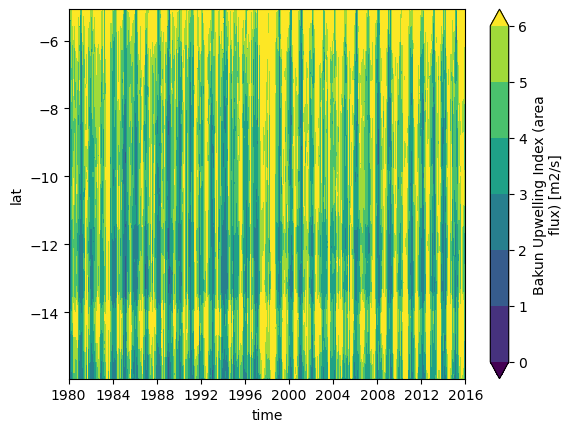

In [6]:
ds = ds.dropna('lat')
ds.BUI.plot.contourf(robust=True,x='time')

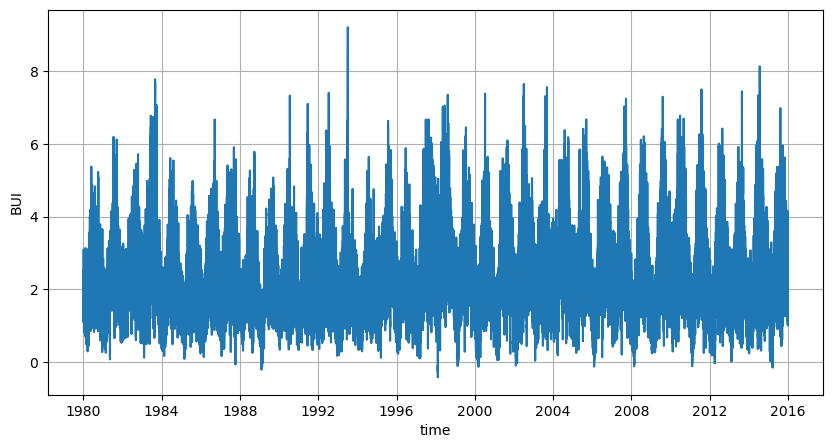

In [8]:
import matplotlib.pyplot as plt

ds.BUI.mean(dim='lat').plot(figsize=(10,5))
plt.grid()

Text(0.5, 1.0, 'Seasonality')

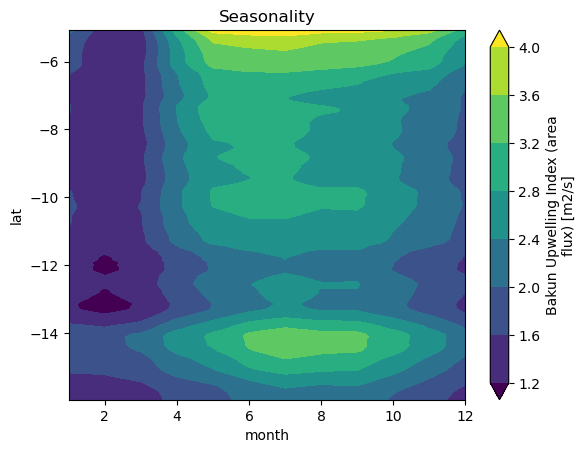

In [9]:
ds.BUI.groupby('time.month').mean().plot.contourf(x='month', robust=True)
plt.title('Seasonality')

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


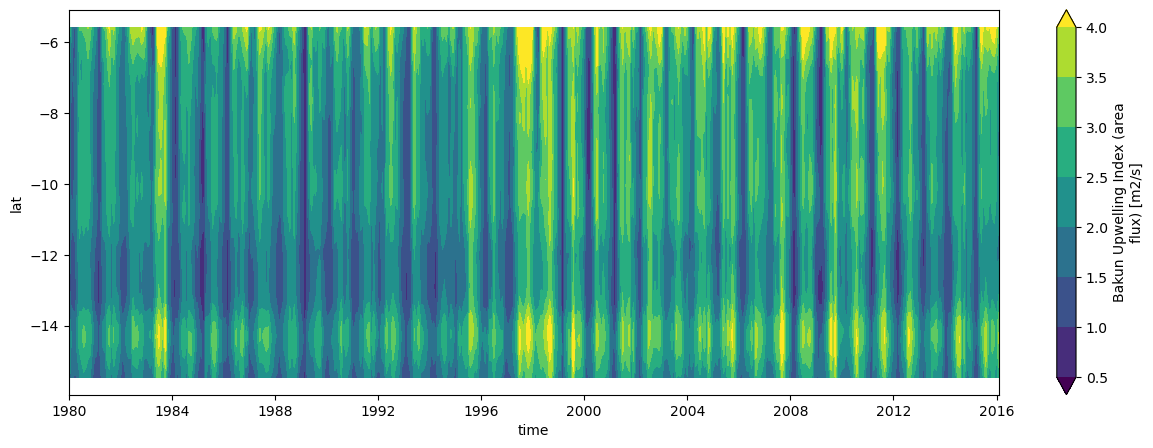

In [11]:
ds.BUI.resample(time='1M').mean().rolling(lat=13, center=True).mean().plot.contourf(x='time',robust=True,figsize=(15,5))

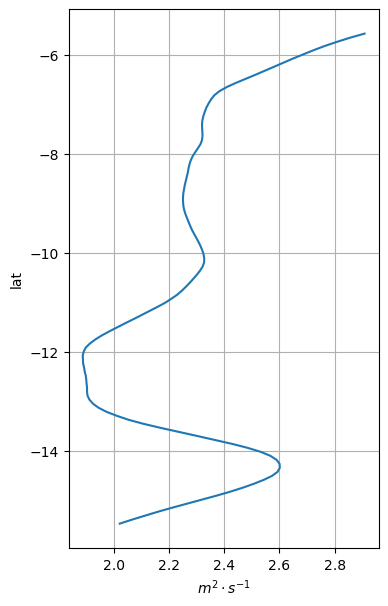

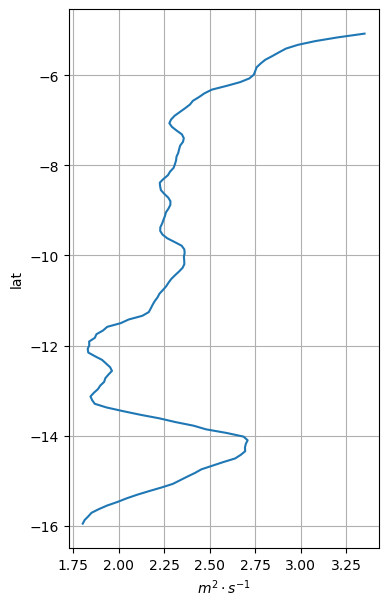

In [13]:
ds.BUI.mean(dim='time').rolling(
    lat=13, center=True).mean().rename('$m^{2} \cdot s^{-1}$').plot(y='lat',figsize=(4,7))
plt.grid()

ds.BUI.mean(dim='time').rename('$m^{2} \cdot s^{-1}$').plot(y='lat',figsize=(4,7))
plt.grid()

In [15]:
# ds.BUI.to_netcdf('BUI/BUI_H.nc')
# ds.BUI.resample(time='1M').mean().to_netcdf('BUI/BUI_M.nc')

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


## Offshore transport of the Cross-shore Ekman

In [25]:
files = sorted(glob.glob('Ekman_crosshore/offshore/Offshore*.nc'))
print(len(files), files[:5], files[-5:])

# Peek at first two
for f in files[:3]:
    with xr.open_dataset(f) as ds:
        print(f, ds['time'].load().values[:3], ds['time'].load().values[-3:])

432 ['Ekman_crosshore/offshore/OffshoreY1980M10_.nc', 'Ekman_crosshore/offshore/OffshoreY1980M11_.nc', 'Ekman_crosshore/offshore/OffshoreY1980M12_.nc', 'Ekman_crosshore/offshore/OffshoreY1981M10_.nc', 'Ekman_crosshore/offshore/OffshoreY1981M11_.nc'] ['Ekman_crosshore/offshore/Offshore_Y2015M5_.nc', 'Ekman_crosshore/offshore/Offshore_Y2015M6_.nc', 'Ekman_crosshore/offshore/Offshore_Y2015M7_.nc', 'Ekman_crosshore/offshore/Offshore_Y2015M8_.nc', 'Ekman_crosshore/offshore/Offshore_Y2015M9_.nc']
Ekman_crosshore/offshore/OffshoreY1980M10_.nc ['1980-09-30T21:59:59.121093747' '1980-09-30T23:00:00.878906252'
 '1980-10-01T00:00:00.000000000'] ['1980-10-31T23:00:00.878906252' '1980-11-01T00:00:00.000000000'
 '1980-11-01T00:59:59.121093747']
Ekman_crosshore/offshore/OffshoreY1980M11_.nc ['1980-10-31T21:59:59.121093747' '1980-10-31T23:00:00.878906252'
 '1980-11-01T00:00:00.000000000'] ['1980-11-30T23:00:00.878906252' '1980-12-01T00:00:00.000000000'
 '1980-12-01T00:59:59.121093747']
Ekman_crosshore/

In [26]:
ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='time',  # name of the time coordinate/dimension to concat
    parallel=True,
    chunks=
        'auto'# Half the spatial dimension
).sortby('time')
ds = ds.compute()
ds

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 317304, lat: 540)
Coordinates:
  * time         (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... ...
  * lat          (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.704 9.787 9.869
Data variables:
    Ek_offshore  (time, lat) float64 1GB nan nan nan nan nan ... nan nan nan nan

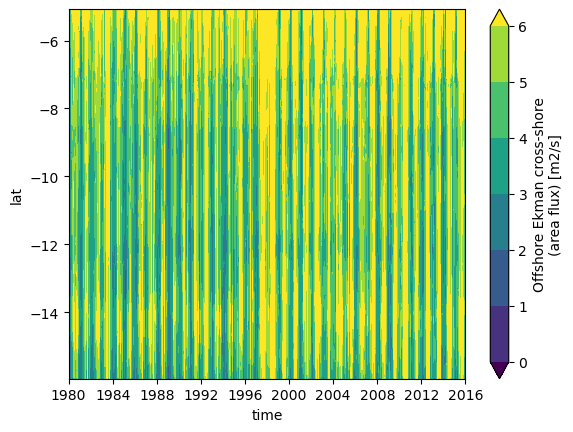

In [27]:
ds = ds.dropna('lat')
ds.Ek_offshore.plot.contourf(robust=True,x='time')

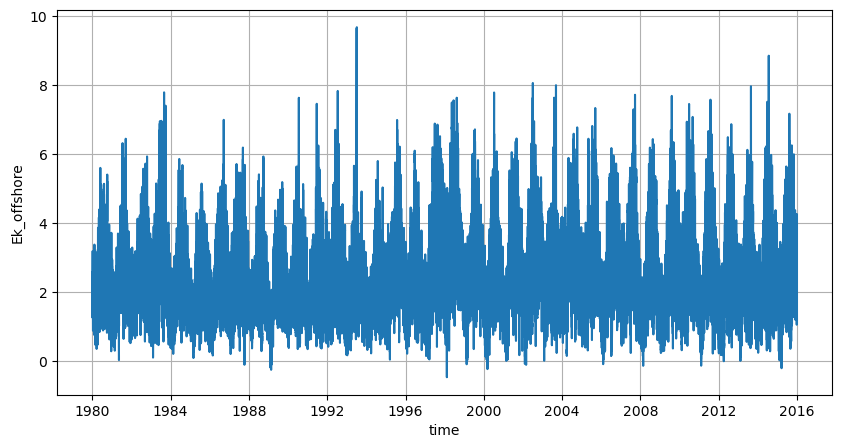

In [28]:
ds.Ek_offshore.mean(dim='lat').plot(figsize=(10,5))
plt.grid()

Text(0.5, 1.0, 'Seasonality')

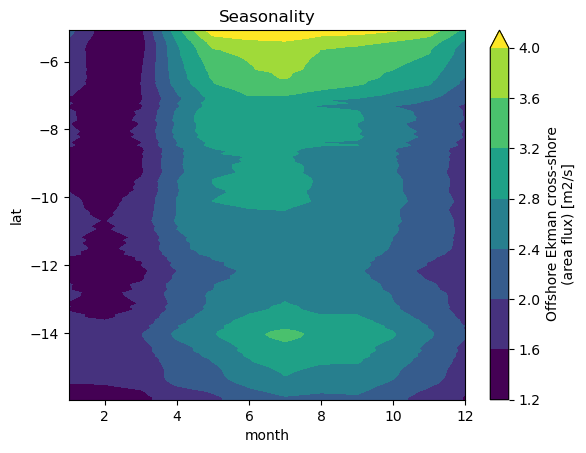

In [29]:
ds.Ek_offshore.groupby('time.month').mean().plot.contourf(x='month', robust=True)
plt.title('Seasonality')

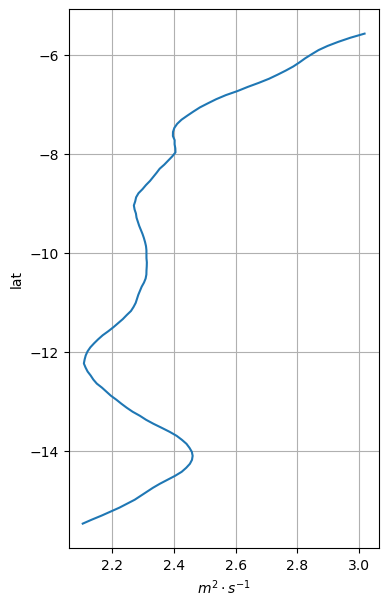

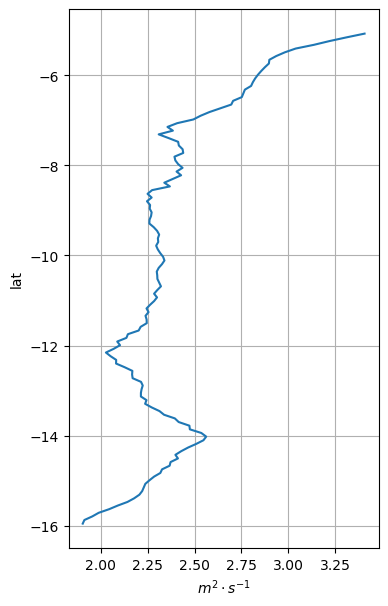

In [30]:
ds.Ek_offshore.mean(dim='time').rolling(
    lat=13, center=True).mean().rename('$m^{2} \cdot s^{-1}$').plot(y='lat',figsize=(4,7))
plt.grid()

ds.Ek_offshore.mean(dim='time').rename('$m^{2} \cdot s^{-1}$').plot(y='lat',figsize=(4,7))
plt.grid()

In [31]:
# ds.Ek_offshore.to_netcdf('Ekman_crosshore/Ek_offshore_H.nc')
# ds.Ek_offshore.resample(time='1M').mean().to_netcdf('Ekman_crosshore/Ek_offshore_M.nc')

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


## Inshore transport of the Cross-shore Ekman

In [32]:
files = sorted(glob.glob('Ekman_crosshore/inshore/Inshore*.nc'))
print(len(files), files[:5], files[-5:])

# Peek at first two
for f in files[:3]:
    with xr.open_dataset(f) as ds:
        print(f, ds['time'].load().values[:3], ds['time'].load().values[-3:])

432 ['Ekman_crosshore/inshore/InshoreY1980M10_.nc', 'Ekman_crosshore/inshore/InshoreY1980M11_.nc', 'Ekman_crosshore/inshore/InshoreY1980M12_.nc', 'Ekman_crosshore/inshore/InshoreY1981M10_.nc', 'Ekman_crosshore/inshore/InshoreY1981M11_.nc'] ['Ekman_crosshore/inshore/Inshore_Y2015M5_.nc', 'Ekman_crosshore/inshore/Inshore_Y2015M6_.nc', 'Ekman_crosshore/inshore/Inshore_Y2015M7_.nc', 'Ekman_crosshore/inshore/Inshore_Y2015M8_.nc', 'Ekman_crosshore/inshore/Inshore_Y2015M9_.nc']
Ekman_crosshore/inshore/InshoreY1980M10_.nc ['1980-09-30T21:59:59.121093747' '1980-09-30T23:00:00.878906252'
 '1980-10-01T00:00:00.000000000'] ['1980-10-31T23:00:00.878906252' '1980-11-01T00:00:00.000000000'
 '1980-11-01T00:59:59.121093747']
Ekman_crosshore/inshore/InshoreY1980M11_.nc ['1980-10-31T21:59:59.121093747' '1980-10-31T23:00:00.878906252'
 '1980-11-01T00:00:00.000000000'] ['1980-11-30T23:00:00.878906252' '1980-12-01T00:00:00.000000000'
 '1980-12-01T00:59:59.121093747']
Ekman_crosshore/inshore/InshoreY1980M12_

In [33]:
ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='time',  # name of the time coordinate/dimension to concat
    parallel=True,
    chunks=
        'auto'# Half the spatial dimension
).sortby('time')
ds = ds.compute()
ds

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 317304, lat: 540)
Coordinates:
  * time        (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2...
  * lat         (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.704 9.787 9.869
Data variables:
    Ek_inshore  (time, lat) float64 1GB nan nan nan nan nan ... nan nan nan nan

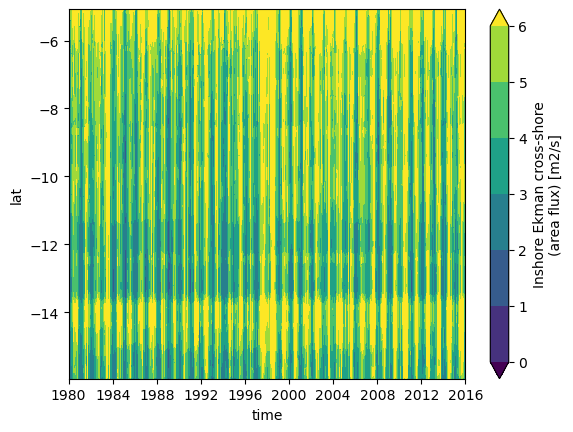

In [34]:
ds = ds.dropna('lat')
ds.Ek_inshore.plot.contourf(robust=True,x='time')

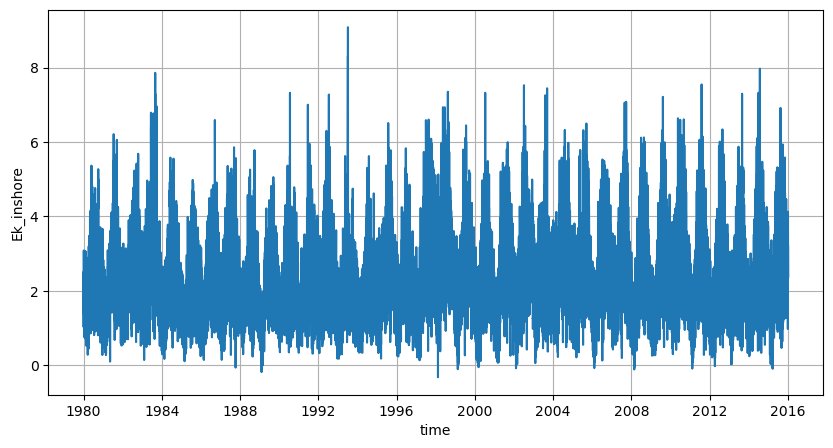

In [35]:
ds.Ek_inshore.mean(dim='lat').plot(figsize=(10,5))
plt.grid()

Text(0.5, 1.0, 'Seasonality')

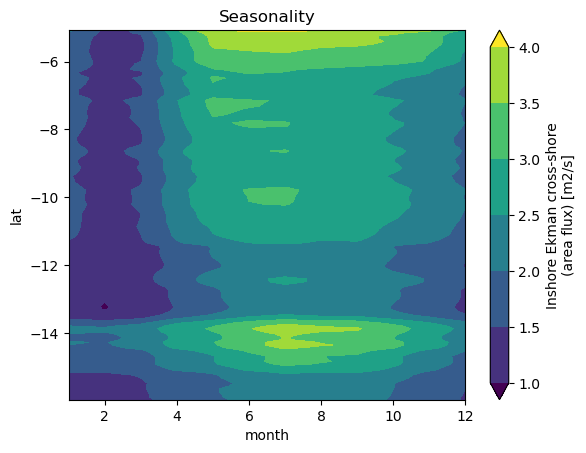

In [36]:
ds.Ek_inshore.groupby('time.month').mean().plot.contourf(x='month', robust=True)
plt.title('Seasonality')

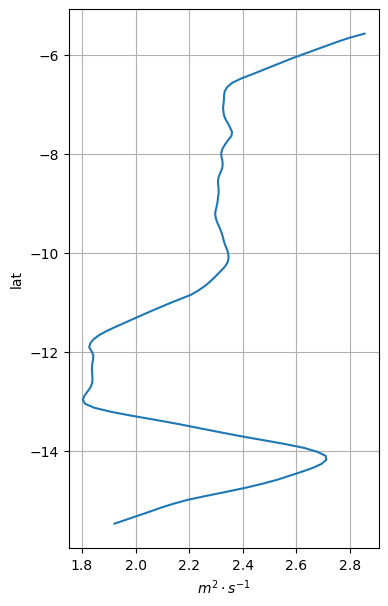

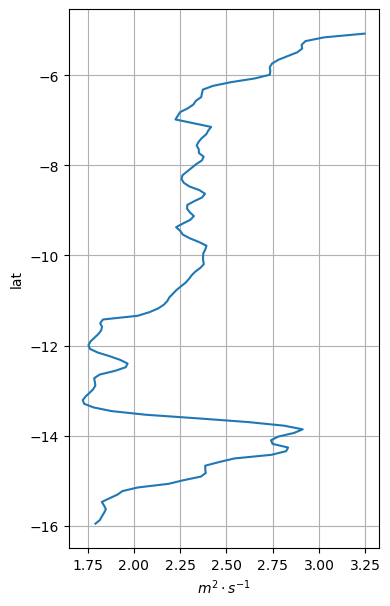

In [37]:
ds.Ek_inshore.mean(dim='time').rolling(
    lat=13, center=True).mean().rename('$m^{2} \cdot s^{-1}$').plot(y='lat',figsize=(4,7))
plt.grid()

ds.Ek_inshore.mean(dim='time').rename('$m^{2} \cdot s^{-1}$').plot(y='lat',figsize=(4,7))
plt.grid()

In [38]:
# ds.Ek_inshore.to_netcdf('Ekman_crosshore/Ek_inshore_H.nc')
# ds.Ek_inshore.resample(time='1M').mean().to_netcdf('Ekman_crosshore/Ek_inshore_M.nc')

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
